In [1]:
import pandas as pd

dfs = []

# Hotel review 1
df1 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\Hotel_review1.csv")

df1 = df1.rename(columns={
'name':'item_name',
'reviews.text':'review_text',
'reviews.rating':'rating',
'reviews.date':'review_time'
})

df1 = df1[['item_name','review_text','rating','review_time','city','country']]

df1['source'] = 'hotel_review1'
dfs.append(df1)


# Hotel review 2
df2 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\Hotel_Review2.csv")

df2 = df2.rename(columns={
'name':'item_name',
'reviews.text':'review_text',
'reviews.rating':'rating',
'reviews.date':'review_time'
})

df2 = df2[['item_name','review_text','rating','review_time','city','country']]

df2['source'] = 'hotel_review2'
dfs.append(df2)


# Hotel review 3
df3 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\Hotel_Review3.csv")

df3 = df3.rename(columns={
'name':'item_name',
'reviews.text':'review_text',
'reviews.rating':'rating',
'reviews.date':'review_time'
})

df3 = df3[['item_name','review_text','rating','review_time','city','country']]

df3['source'] = 'hotel_review3'
dfs.append(df3)


# Hotel review 4
df4 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\hotel_review4.csv")

df4 = df4.rename(columns={
'hotel_name':'item_name',
'review':'review_text',
'score':'rating'
})

df4['review_time'] = None
df4['city'] = None
df4['country'] = None

df4 = df4[['item_name','review_text','rating','review_time','city','country']]

df4['source'] = 'hotel_review4'
dfs.append(df4)


# Hotel review 5
df5 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\Hotel_Review5.csv")

df5 = df5.rename(columns={
'Review':'review_text',
'Rating':'rating'
})

df5['item_name'] = 'hotel'
df5['review_time'] = None
df5['city'] = None
df5['country'] = None

df5 = df5[['item_name','review_text','rating','review_time','city','country']]

df5['source'] = 'hotel_review5'
dfs.append(df5)


# Hotel review 6
df6 = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\hotel-reviews\Hotel_Review6.csv")

df6['review_text'] = df6['Positive_Review'] + " " + df6['Negative_Review']

df6 = df6.rename(columns={
'Hotel_Name':'item_name',
'Reviewer_Score':'rating',
'Review_Date':'review_time'
})

df6['city'] = None
df6['country'] = None

df6 = df6[['item_name','review_text','rating','review_time','city','country']]

df6['source'] = 'hotel_review6'
dfs.append(df6)


hotel_df = pd.concat(dfs, ignore_index=True)

hotel_df['review_id'] = range(len(hotel_df))

hotel_df = hotel_df[['review_id','source','item_name','review_text','rating','review_time','city','country']]

hotel_df.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\hotel_reviews.csv",index=False)

print("Hotel dataset size:",hotel_df.shape)

Hotel dataset size: (601546, 8)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Consistent plot style across all notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
print(f"Shape: {hotel_df.shape}")
print(f"Rating range: {hotel_df['rating'].min()} – {hotel_df['rating'].max()}")
print(f"Missing values:\n{hotel_df.isnull().sum()}")

Shape: (601546, 8)
Rating range: 0.0 – 10.0
Missing values:
review_id           0
source              0
item_name           0
review_text        25
rating            862
review_time     30155
city           545634
country        545634
dtype: int64


rating
0.00        337
1.00       7509
1.25          2
1.30          1
1.45          6
          ...  
9.20      58632
9.40         63
9.50        725
9.60      71220
10.00    115954
Name: count, Length: 71, dtype: int64

High-rating share (4–5★): 10.7%


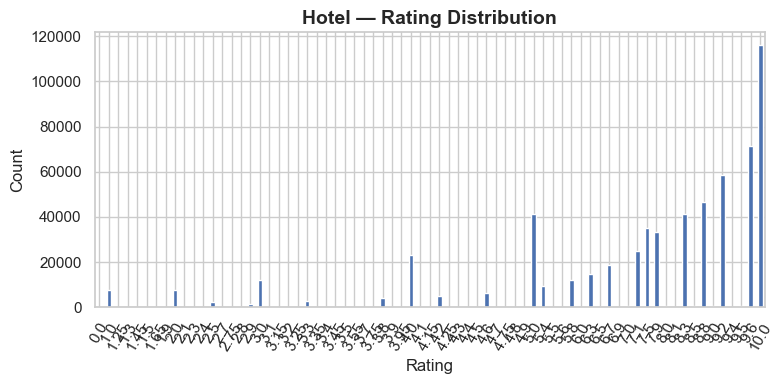

In [6]:
rating_counts = hotel_df["rating"].value_counts().sort_index()
print(rating_counts)
print(f"\nHigh-rating share (4–5★): {rating_counts[[4,5]].sum() / len(hotel_df):.1%}")

# Cell 2 — Rating Distribution
fig, ax = plt.subplots(figsize=(8, 4))
hotel_df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#4C72B0", edgecolor="white"
)
ax.set_title("Hotel — Rating Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\rating_distribution.png", dpi=150)
plt.show()

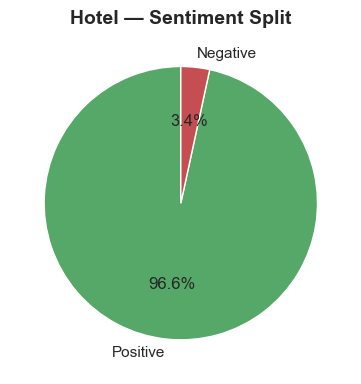

In [7]:
# Cell 3 — Sentiment Split
fig, ax = plt.subplots(figsize=(5, 4))
sentiment = hotel_df["rating"].apply(lambda x: "Positive" if x >= 3 else "Negative")
sentiment.value_counts().plot(
    kind="pie", ax=ax, autopct="%1.1f%%",
    colors=["#55A868", "#C44E52"], startangle=90
)
ax.set_title("Hotel — Sentiment Split", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\sentiment_split.png", dpi=150)
plt.show()

count    601521.000000
mean        226.744024
std         274.455043
min           1.000000
25%          74.000000
50%         146.000000
75%         282.000000
max       14254.000000
Name: review_length, dtype: float64


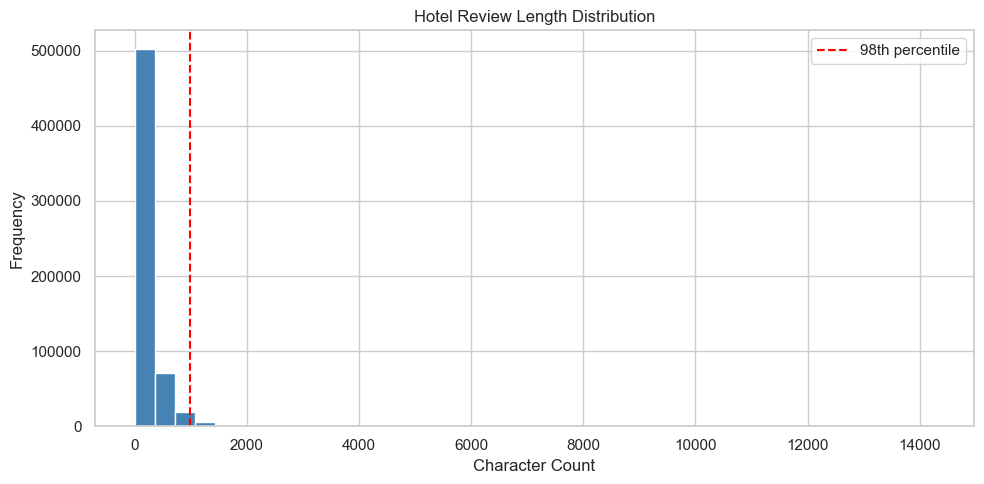

In [8]:
hotel_df["review_length"] = hotel_df["review_text"].str.len()

print(hotel_df["review_length"].describe())

hotel_df["review_length"].hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Hotel Review Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.axvline(hotel_df["review_length"].quantile(0.98), color="red", linestyle="--", label="98th percentile")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\review_length.png", dpi=150)
plt.show()

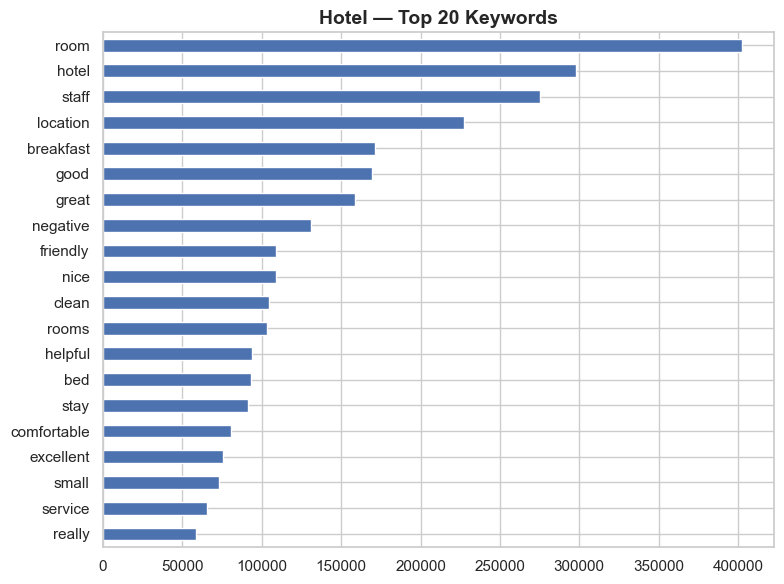

In [9]:
# Cell 5 — Top 20 Keywords
from sklearn.feature_extraction.text import CountVectorizer
cv   = CountVectorizer(max_features=20, stop_words="english")
X    = cv.fit_transform(hotel_df["review_text"].dropna().astype(str))
freq = pd.Series(X.toarray().sum(axis=0), index=cv.get_feature_names_out())
freq = freq.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
freq.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Hotel — Top 20 Keywords", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\top_keywords.png", dpi=150)
plt.show()

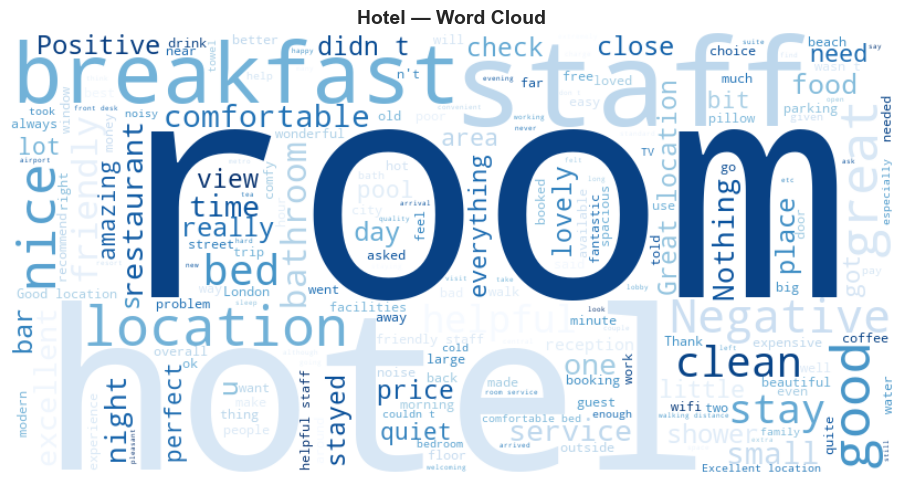

In [10]:
from wordcloud import WordCloud
# Cell 6 — Word Cloud
text = " ".join(hotel_df["review_text"].dropna().astype(str).sample(5000))
wc   = WordCloud(
    width=800, height=400,
    background_color="white",
    colormap="Blues", max_words=200
).generate(text)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Hotel — Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\wordcloud.png", dpi=150)
plt.show()

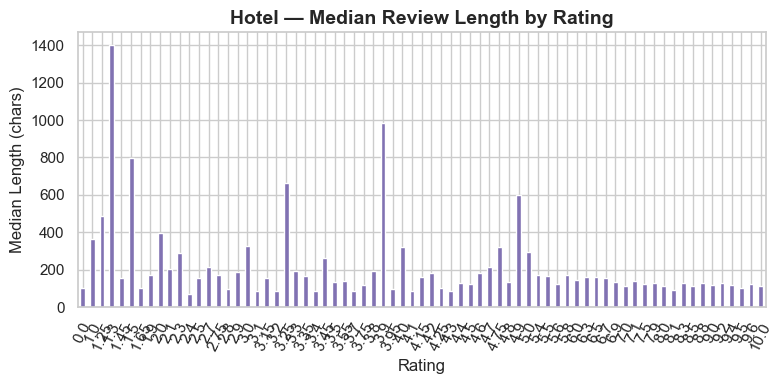


All Hotel EDA images saved to reports/eda/hotel/


In [12]:
# Cell 7 — Rating vs Review Length
fig, ax = plt.subplots(figsize=(8, 4))
hotel_df.groupby("rating")["review_length"].median().plot(
    kind="bar", ax=ax, color="#8172B2", edgecolor="white"
)
ax.set_title("Hotel — Median Review Length by Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Median Length (chars)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=64)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\hotel\length_by_rating.png", dpi=150)
plt.show()

print("\nAll Hotel EDA images saved to reports/eda/hotel/")